In [30]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [31]:
import sqlite3
from typing import Literal
from langchain_core.tools import tool

DB_PATH = "ap_exceptions.db"

def run_query(sql, params=()):
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    rows = [dict(row) for row in conn.execute(sql, params).fetchall()]
    conn.close()
    return rows

In [32]:
@tool
def get_invoice(invoice_id: str) -> dict:
    """Get one supplier invoice by id, for example INV-1044."""
    rows = run_query("SELECT * FROM invoices WHERE invoice_id = ?", (invoice_id,))
    return rows[0] if rows else {"error": f"No invoice {invoice_id}"}

@tool
def get_purchase_order(po_id: str) -> dict:
    """Get the original purchase order (agreed item, quantity, unit price) by id, for example PO-17."""
    rows = run_query("SELECT * FROM purchase_orders WHERE po_id = ?", (po_id,))
    return rows[0] if rows else {"error": f"No purchase order {po_id}"}


@tool
def get_receipt(po_id: str) -> dict:
    """Get how many units the warehouse actually received for a purchase order."""
    rows = run_query("SELECT * FROM receipts WHERE po_id = ?", (po_id,))
    return rows[0] if rows else {"error": f"No receipt for {po_id}"}


@tool
def compare_prices(invoice_unit_price: float, po_unit_price: float, quantity: int) -> dict:
    """Calculate how far the invoice unit price is above the PO unit price."""
    unit_difference = invoice_unit_price - po_unit_price
    return {
        "unit_difference": round(unit_difference, 2),
        "total_difference": round(unit_difference * quantity, 2),
        "percent_over": round(unit_difference / po_unit_price * 100, 2),
    }



In [33]:
@tool
def get_price_tolerance() -> dict:
    """Get the company's price tolerance rule (max_percent)."""
    return run_query("SELECT * FROM policy WHERE rule_name = 'price_tolerance'")[0]

In [34]:
@tool
def get_po_amendments(po_id: str) -> dict:
    """List official price amendments for a purchase order. An empty list means the price was never changed."""
    rows = run_query(
        "SELECT * FROM po_amendments WHERE po_id = ? ORDER BY effective_date", (po_id,)
    )
    return {"po_id": po_id, "amendments": rows}


In [35]:
@tool
def update_case(
    invoice_id: str,
    status: Literal["Approved to pay", "Credit requested"],
    note: str,
) -> dict:
    """Record the final decision on an invoice and return the updated row."""
    conn = sqlite3.connect(DB_PATH)
    conn.execute(
        "UPDATE invoices SET status = ?, note = ? WHERE invoice_id = ?",
        (status, note, invoice_id),
    )
    conn.commit()
    conn.close()
    rows = run_query(
        "SELECT invoice_id, status, note FROM invoices WHERE invoice_id = ?", (invoice_id,)
    )
    return rows[0] if rows else {"error": f"No invoice {invoice_id}"}

In [36]:

matcher_tools = [get_invoice, get_purchase_order, get_receipt, compare_prices]
policy_tools = [get_price_tolerance]
contract_tools = [get_po_amendments]
case_tools = [update_case]

In [37]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)

COMMON_RULES = """
Never ask for confirmation. Work autonomously.
Keep your answer short: a few lines of findings, then the CONCLUSION line.
"""


In [38]:
matcher_agent = create_agent(
    model=llm,
    tools=matcher_tools,
    system_prompt="""You are the Matcher on an accounts-payable review desk.
You compare a supplier invoice with its purchase order (PO) and goods receipt.

Steps:
1. get_invoice for the invoice in the request. Note its po_id.
2. get_purchase_order and get_receipt for that po_id.
3. Check that invoice quantity, PO quantity, and received quantity agree.
4. Call compare_prices with the invoice unit price, the PO unit price, and the invoice quantity.

RE-MATCH RULE: If the conversation contains a ContractChecker message with AMENDMENT FOUND for this PO,
use the amended unit price as the PO unit price in compare_prices, and use RE-MATCH in your conclusion.

End with exactly one line in one of these forms:
CONCLUSION: MATCH INV-1044 (PO PO-17). Quantity matches. Invoice 112 vs PO 100: 12.0 percent over, 120.0 total.
CONCLUSION: RE-MATCH INV-1044 (PO PO-17) using amended price 110. Quantity matches. Invoice 112 vs PO 110: 1.82 percent over, 20.0 total.
""" + COMMON_RULES,
)

In [39]:
policy_agent = create_agent(
    model=llm,
    tools=policy_tools,
    system_prompt="""You are the PolicyChecker on an accounts-payable review desk.
You decide whether a price gap is acceptable under company policy.

Use the MOST RECENT Matcher conclusion in the conversation (MATCH or RE-MATCH).
Call get_price_tolerance to read max_percent. Compare percent_over with max_percent.
You cannot see invoices, POs, or amendments. Never invent numbers.

End with exactly one line in one of these forms:
CONCLUSION: WITHIN TOLERANCE. 1.82 percent is within the 5 percent limit. Approve payment.
CONCLUSION: EXCEEDS TOLERANCE. 12.0 percent is above the 5 percent limit. Extra charge is 120.0.

If the user only asks about the policy itself, report it and end with:
CONCLUSION: POLICY. Invoice price may be at most 5 percent above the PO.
""" + COMMON_RULES,
)

In [40]:
contract_agent = create_agent(
    model=llm,
    tools=contract_tools,
    system_prompt="""You are the ContractChecker on an accounts-payable review desk.
You check whether a purchase order's price was officially amended.

Find the PO id in the Matcher's conclusion or in the user's request.
Call get_po_amendments for it. If there are several amendments, the latest effective_date wins.

End with exactly one line in one of these forms:
CONCLUSION: AMENDMENT FOUND. PO-17 unit price changed to 110 on 2026-09-01 (reason).
CONCLUSION: NO AMENDMENT. PO-18 price is unchanged.
""" + COMMON_RULES,
)


In [41]:
case_agent = create_agent(
    model=llm,
    tools=case_tools,
    system_prompt="""You are the CaseUpdater on an accounts-payable review desk.
You record the final decision on the invoice from the user's request.

Read the MOST RECENT PolicyChecker conclusion:
- WITHIN TOLERANCE  -> status "Approved to pay"
- EXCEEDS TOLERANCE -> status "Credit requested"
Write a one-sentence note with the percent over, the 5 percent limit, and the credit amount if any.
If an amended PO price was used, mention the amendment in the note.
Call update_case once. Do not recalculate anything.

End with exactly one line. The status in that line must be the same status you passed to update_case:
CONCLUSION: CASE UPDATED. INV-1044 is now Approved to pay.
CONCLUSION: CASE UPDATED. INV-1045 is now Credit requested.
""" + COMMON_RULES,
)

In [42]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from pydantic import BaseModel, Field

supervisor_prompt = """
You are the supervisor of an accounts-payable review desk. You do not do the work yourself.
After each worker reports, read the whole conversation and decide who should act next.

Your workers:
- Matcher: compares invoice vs PO vs receipt. Can re-match using an amended PO price.
- PolicyChecker: decides whether a price gap is within the allowed tolerance.
- ContractChecker: checks whether the PO price was officially amended.
- CaseUpdater: records the final decision on the invoice.

STEP 1: Look at the user's FIRST message and classify it:
- RESOLVE: the user asks to resolve, review, or process an invoice.
- QUESTION: the user asks for one fact (for example "Has PO-17 been amended?" or "What is our price tolerance?").

STEP 2 for RESOLVE requests: follow this playbook. Base every decision on the latest findings:
- No Matcher conclusion yet -> Matcher.
- The most recent worker message is from Matcher -> PolicyChecker (new numbers need a policy verdict).
- PolicyChecker says WITHIN TOLERANCE -> CaseUpdater.
- PolicyChecker says EXCEEDS TOLERANCE:
    - ContractChecker has not run yet -> ContractChecker (maybe the PO price was changed).
    - ContractChecker already ran -> CaseUpdater (nothing else can explain the gap).
- ContractChecker says AMENDMENT FOUND -> Matcher (re-match against the amended price).
- ContractChecker says NO AMENDMENT -> CaseUpdater.
- CaseUpdater says CASE UPDATED -> FINISH.

STEP 2 for QUESTION requests: the playbook above does NOT apply.
- No worker has answered yet -> the one worker who owns that fact
  (amendments -> ContractChecker, tolerance or policy -> PolicyChecker, invoice or PO details -> Matcher).
- That worker has posted its CONCLUSION -> FINISH. Do not re-match, apply policy, or update any case.
- You cannot answer questions yourself, so never FINISH before a worker has answered.

Safety limits: ContractChecker at most once per request. CaseUpdater at most once per request.
"""

In [43]:
prompt = ChatPromptTemplate.from_messages([
    ("system", supervisor_prompt),
    MessagesPlaceholder(variable_name="messages"),
    ("system", "Based on the findings so far, who should act next? Or should we FINISH?"),
])

In [44]:
class Route(BaseModel):
    request_type: Literal["RESOLVE", "QUESTION"] = Field(description="Classification of the user's first message.")
    reason: str = Field(description="One short sentence: what the latest finding is and why this is the next step.")
    next: Literal["Matcher", "PolicyChecker", "ContractChecker", "CaseUpdater", "FINISH"]

In [45]:
chain = prompt | llm.with_structured_output(Route)

In [46]:
import operator
from typing_extensions import TypedDict, Annotated
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, END

class AgentState(TypedDict):
    messages: Annotated[list, operator.add]
    next: str

In [47]:
def supervisor_node(state: AgentState) -> AgentState:
    route = chain.invoke({"messages": state["messages"]})

    print(f"\n>>> SUPERVISOR [{route.request_type}] -> {route.next}   (reason: {route.reason})")
    
    return {"next": route.next}

In [48]:
def agent_node(agent, name):
    """Wrap a worker so it runs on the shared conversation and labels its reply."""
    def node(state):
        result = agent.invoke({"messages": state["messages"]})
        content = result["messages"][-1].content
        print(f"\n[{name}]\n{content}")
        return {"messages": [HumanMessage(content=f"{name}: {content}", name=name)]}
    return node


matcher_node = agent_node(matcher_agent, "Matcher")
policy_node = agent_node(policy_agent, "PolicyChecker")
contract_node = agent_node(contract_agent, "ContractChecker")
case_node = agent_node(case_agent, "CaseUpdater")





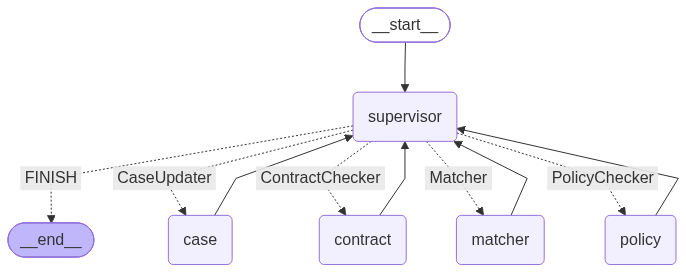

In [49]:
workflow = StateGraph(AgentState)
workflow.add_node("supervisor", supervisor_node)
workflow.add_node("matcher", matcher_agent  )
workflow.add_node("policy", policy_agent)
workflow.add_node("contract", contract_agent)
workflow.add_node("case", case_agent)

workflow.set_entry_point("supervisor")

workflow.add_conditional_edges("supervisor" , lambda state: state["next"], {
    "Matcher": "matcher",
    "PolicyChecker": "policy",
    "ContractChecker": "contract",
    "CaseUpdater": "case",
    "FINISH": END,
}
   
)
workflow.add_edge("matcher", "supervisor")
workflow.add_edge("policy", "supervisor")
workflow.add_edge("contract", "supervisor")
workflow.add_edge("case", "supervisor")

graph = workflow.compile()

graph




In [50]:
result = graph.invoke({"messages": [HumanMessage(content="  Resolve on-hold invoice INV-1044")]})
result


>>> SUPERVISOR [RESOLVE] -> Matcher   (reason: No worker has reported yet, so the invoice must first be compared against the PO and receipt.)

>>> SUPERVISOR [RESOLVE] -> PolicyChecker   (reason: Matcher has already reported a price gap of 12% over the PO, so the next step is a policy verdict on whether that gap is within tolerance.)

>>> SUPERVISOR [RESOLVE] -> ContractChecker   (reason: The latest finding is that the price gap exceeds tolerance, so we must check whether the PO was officially amended before updating the case.)

>>> SUPERVISOR [RESOLVE] -> Matcher   (reason: ContractChecker found an official amendment, so the invoice should be re-matched against the amended PO price.)

>>> SUPERVISOR [RESOLVE] -> PolicyChecker   (reason: Matcher has already re-matched on the amended PO price and the latest finding is a 1.82% gap, so the next step is a policy verdict on the new numbers.)

>>> SUPERVISOR [RESOLVE] -> CaseUpdater   (reason: Latest finding is WITHIN TOLERANCE after re-mat

{'messages': [HumanMessage(content='  Resolve on-hold invoice INV-1044', additional_kwargs={}, response_metadata={}, id='36c8bed1-1cbf-4a72-bc25-eaf5ca5b6ca9'),
  HumanMessage(content='  Resolve on-hold invoice INV-1044', additional_kwargs={}, response_metadata={}, id='36c8bed1-1cbf-4a72-bc25-eaf5ca5b6ca9'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 517, 'total_tokens': 538, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EVWDBSMwzHRCz2uS2mpyAHJBU1fmL', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc